In [71]:
# Import torch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
print(torch.__version__)
print(torchvision.__version__)


2.11.0+cpu
0.26.0+cpu


# 1. Getting a dataset

In [72]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

In [73]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [74]:
dir(train_data)[40:]

['class_to_idx',
 'classes',
 'data',
 'download',
 'extra_repr',
 'mirrors',
 'processed_folder',
 'raw_folder',
 'resources',
 'root',
 'target_transform',
 'targets',
 'test_data',
 'test_file',
 'test_labels',
 'train',
 'train_data',
 'train_labels',
 'training_file',
 'transform',
 'transforms']

In [75]:
image, label = train_data[0]
image,label


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [76]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [77]:
train_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [78]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [79]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [80]:
train_data.transforms

StandardTransform
Transform: ToTensor()

In [81]:
len(train_data), len(test_data)

(60000, 10000)

### 1.2 Vidualizing data

torch.Size([1, 28, 28])
torch.Size([28, 28, 1])


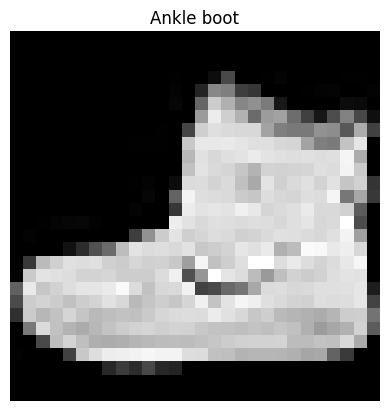

In [82]:
import matplotlib.pyplot as plt

print(image.shape)
print(image.permute((1,2,0)).shape)
# plt.imshow(image.permute((1,2,0)),cmap='gray');
plt.title(train_data.classes[label])
plt.axis(False)
plt.imshow(image.squeeze(),cmap='gray');

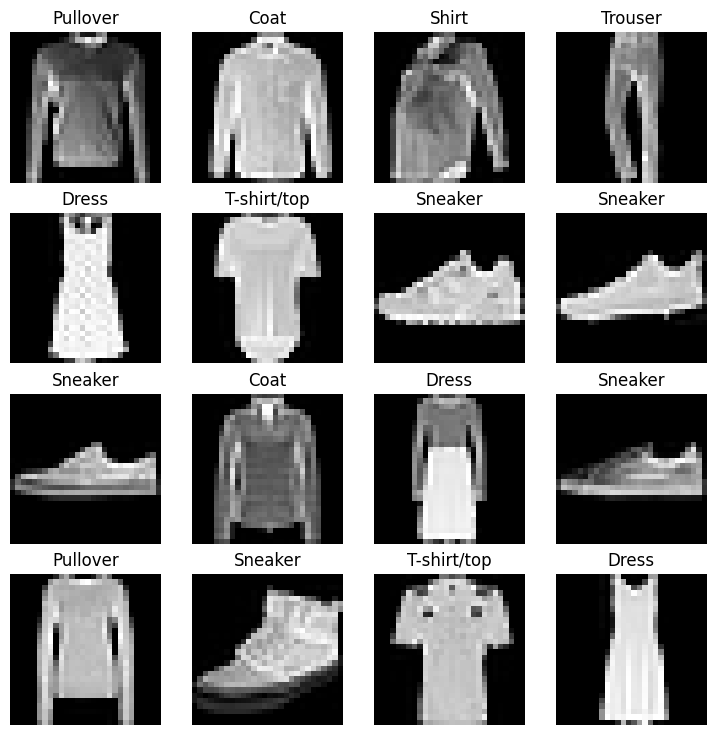

In [83]:
rows, cols = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(9,9))
for i in range(rows):
    for j in range(cols):
        random_idx = torch.randint(0, len(train_data), size=[1]).item()
        img, label = train_data[random_idx]

        axes[i, j].set_title(train_data.classes[label])
        axes[i, j].axis(False)
        axes[i, j].imshow(img.squeeze(),cmap='gray');

## 2. Prepare DataLoader

DataLoader turns dataset into a Python interable.

In [84]:
from torch.utils.data import DataLoader
# Turn datasets into iterable
train_dataloader = DataLoader(dataset=train_data,
                                    batch_size=32,
                                    shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                                        batch_size=32,
                                        shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x23031ca06b0>,
 <torch.utils.data.dataloader.DataLoader at 0x23035e012e0>)

In [85]:
len(train_dataloader), len(test_dataloader)

(1875, 313)

In [86]:
# g
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

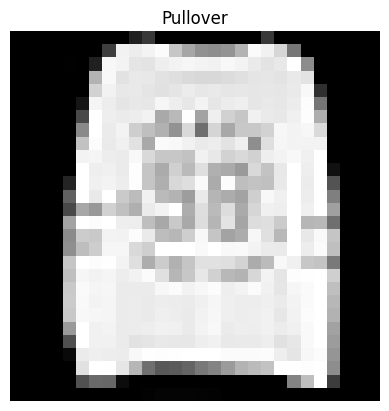

In [87]:
# Visualize sample
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch),size=[1])
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.title(train_data.classes[label])
plt.axis(False)
plt.imshow(img.squeeze(), cmap='gray');

## 3. Model 0: Build a basline model

Start simply and add complexity when necessary

In [88]:
# Create a flatten 
flatten_model = nn.Flatten()

x = train_features_batch[0]
x.shape

torch.Size([1, 28, 28])

In [89]:
output = flatten_model(x)
output.shape

torch.Size([1, 784])

In [90]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, 
                input_shape: int,
                hidden_units: int,
                output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                        out_features=hidden_units),
            nn.Linear(in_features=hidden_units,
                        out_features=output_shape)
        )
    
    def forward(self, x:torch.Tensor):
        return self.layer_stack(x)

In [91]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(
    input_shape=(28*28),
    hidden_units=10,
    output_shape=len(class_name)
)
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

### 3.1 Setup loss, Optimizer, Evaluation metrics

In [92]:
from torchmetrics import Accuracy

accuracy_fn = Accuracy(task='multiclass', 
                    num_classes=len(class_name))

In [93]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                                lr=0.01)

                              

### 3.2 Creating function to time experiments

In [94]:
from timeit import default_timer as timer
from torch import profiler
def print_train_time(start: float,
                    end: float,
                    device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### 3.3 Creating a training loop 

In [95]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n------")

    ### Training
    train_loss = 0
    train_acc = 0
    # Add a loop to loop through the training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        # 1. Forward pass
        y_logits = model_0(X)
        # y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

        # 2. Calculate loss
        loss = loss_fn(y_logits, y)
        train_loss += loss
        train_acc += accuracy_fn(y_logits.argmax(dim=1), y)

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")
    
    # Calculate avg loss 
    train_loss /= len(train_dataloader)   

    # Calculate avd acc
    train_acc /= len(train_dataloader)   
    

    ### Testing
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_logits = model_0(X)
            # test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

            # 2. Calculate loss
            test_loss += loss_fn(test_logits, y)

            # 3. Calculate accuracy
            test_acc += accuracy_fn(test_logits.argmax(dim=1), y)

        # Calculate avg test loss 
        test_loss /= len(test_dataloader)

        # Calculate avg test accuracy 
        test_acc /= len(test_dataloader)
    print(f"\nTrain loss:{train_loss:.4f}, Train acc: {train_acc:.4f} | Test loss:{test_loss:.4f}, Test acc: {test_acc:.4f}")

# Calculate training time
train_time_end = timer()
total_train_time_model_0 = print_train_time(start=train_time_start,
                                        end=train_time_end,
                                        device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 33%|███▎      | 1/3 [00:04<00:09,  4.97s/it]


Train loss:0.9096, Train acc: 0.7087 | Test loss:0.6290, Test acc: 0.7863
Epoch: 1
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 67%|██████▋   | 2/3 [00:10<00:05,  5.06s/it]


Train loss:0.5573, Train acc: 0.8109 | Test loss:0.5441, Test acc: 0.8113
Epoch: 2
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


100%|██████████| 3/3 [00:14<00:00,  4.97s/it]


Train loss:0.5027, Train acc: 0.8275 | Test loss:0.5137, Test acc: 0.8200
Train time on cpu: 14.921 seconds


## 4. Agnostic Device

In [96]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 5. Make prediction and get model0 results

In [97]:
torch.manual_seed(42)
def eval_model(model: nn.Module,
                data_loader: torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                accuracy_fn,
                device: torch.device = device):

    loss, acc = 0,0 
    model.eval()
    with torch.inference_mode():
        
        for X, y in tqdm(data_loader):
            X, y = X.to(device), y.to(device)
            y_preds = model(X)

            loss += loss_fn(y_preds, y)
            acc += accuracy_fn(y_preds.argmax(dim=1), y)

        # Avg loss/acc
        loss /= len(data_loader) 
        acc /= len(data_loader) 

    return {"model_name":model.__class__.__name__,
            "model_loss":loss.item(),
            "model_acc":acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn)

model_0_results


100%|██████████| 313/313 [00:00<00:00, 549.04it/s]


{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5136752128601074,
 'model_acc': tensor(0.8200)}

## 6. Model 1: Building a better model with non-linearity

In [98]:
# Create model with non-linear and linear model
class FashionMNISTModelV1(nn.Module):
    def __init__(self,
                input_shape: int,
                hidden_units: int,
                output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                        out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,
                        out_features=output_shape),
            nn.ReLU()
        )
    def forward(self, x:torch.Tensor):
        return self.layer_stack(x)



In [99]:
# Create an instance of model_1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784,
                            hidden_units=10,
                            output_shape=len(class_name)).to(device)
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

### 6.1 Loss  Optimizer

In [100]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                                lr=0.01)
                              

### 6.2 Functionizing train/test loop

In [101]:
def train_step(model: torch.nn.Module,
                data_loader: torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                optimizer: torch.optim.Optimizer,
                accuracy_fn,
                device: torch.device = device):

    train_loss = 0
    train_acc = 0
    
    # Put model into train mode
    model.train()
    
    # Add a loop to loop through the training batches
    for batch, (X, y) in enumerate(data_loader):
        # Put data on target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_logits = model(X)
        # y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

        # 2. Calculate loss and accuracy
        loss = loss_fn(y_logits, y)
        train_loss += loss
        train_acc += accuracy_fn(y_logits.argmax(dim=1), y)

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate avg test loss and accuracy 
    train_loss /= len(data_loader)   
    train_acc /= len(data_loader)   

    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.4f}")

    

In [102]:
def test_step(model: torch.nn.Module,
                data_loader: torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                accuracy_fn,
                device: torch.device = device):
    ### Testing
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send the data to the target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_logits = model(X)
            # test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

            # 2. Calculate loss
            test_loss += loss_fn(test_logits, y)

            # 3. Calculate accuracy
            test_acc += accuracy_fn(test_logits.argmax(dim=1), y)

        # Calculate avg test loss and accuracy 
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

    print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")


In [103]:
torch.manual_seed(42)

# Measure time
train_time_start = timer()

# Set epochs
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----")
    train_step(model=model_1,
                data_loader=train_dataloader,
                loss_fn=loss_fn,
                optimizer=optimizer,
                accuracy_fn=accuracy_fn)
    
    test_step(model=model_1,
                data_loader=train_dataloader,
                loss_fn=loss_fn,
                accuracy_fn=accuracy_fn)

train_time_end = timer()
total_train_time_model_1 = print_train_time(start=train_time_start,
                                            end=train_time_end,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Train loss: 1.42179 | Train acc: 0.5429


 33%|███▎      | 1/3 [00:08<00:16,  8.23s/it]

Test loss: 1.1052 | Test acc: 0.6305
Epoch: 1
-----
Train loss: 1.03357 | Train acc: 0.6457


 67%|██████▋   | 2/3 [00:18<00:09,  9.15s/it]

Test loss: 0.9805 | Test acc: 0.6574
Epoch: 2
-----
Train loss: 0.95979 | Train acc: 0.6612


100%|██████████| 3/3 [00:27<00:00,  9.33s/it]

Test loss: 0.9368 | Test acc: 0.6679
Train time on cpu: 27.983 seconds


In [104]:
# Model_1 results decitionary
model_1_results = eval_model(model=model_1,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn)
model_1_results

100%|██████████| 313/313 [00:00<00:00, 487.26it/s]


{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.9601633548736572,
 'model_acc': tensor(0.6562)}

In [105]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5136752128601074,
 'model_acc': tensor(0.8200)}

## 7. Model 2: Building a CNN

In [106]:
# Create a convoluational nerual network
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape:int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                        out_channels=hidden_units,
                        kernel_size=3,
                        stride=1,
                        padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                        out_channels=hidden_units,
                        kernel_size=3,
                        stride=1,
                        padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)

        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                        out_channels=hidden_units,
                        kernel_size=3,
                        stride=1,
                        padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                        out_channels=hidden_units,
                        kernel_size=3,
                        stride=1,
                        padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                        out_features=output_shape)
        )

    def forward(self, x:torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

In [107]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
                                hidden_units=10,
                                output_shape=len(class_name)).to(device)

In [108]:
model_2.eval()
with torch.inference_mode():
    y_logits = model_2(image.unsqueeze(0).to(device))
y_logits

tensor([[ 0.0246, -0.0644,  0.0551, -0.0360, -0.0139,  0.0113, -0.0014, -0.0075,
          0.0213,  0.0076]])

### 7.1 Model summary

In [109]:
from torchinfo import summary

summary(model_2, input_size=(32, 1, 28 , 28))

Layer (type:depth-idx)                   Output Shape              Param #
FashionMNISTModelV2                      [32, 10]                  --
├─Sequential: 1-1                        [32, 10, 14, 14]          --
│    └─Conv2d: 2-1                       [32, 10, 28, 28]          100
│    └─ReLU: 2-2                         [32, 10, 28, 28]          --
│    └─Conv2d: 2-3                       [32, 10, 28, 28]          910
│    └─ReLU: 2-4                         [32, 10, 28, 28]          --
│    └─MaxPool2d: 2-5                    [32, 10, 14, 14]          --
├─Sequential: 1-2                        [32, 10, 7, 7]            --
│    └─Conv2d: 2-6                       [32, 10, 14, 14]          910
│    └─ReLU: 2-7                         [32, 10, 14, 14]          --
│    └─Conv2d: 2-8                       [32, 10, 14, 14]          910
│    └─ReLU: 2-9                         [32, 10, 14, 14]          --
│    └─MaxPool2d: 2-10                   [32, 10, 7, 7]            --
├─Sequentia

### 7.2 Setup a loss function and optimizer

In [110]:
# Setup loss function/eval metrics/optimizer
from torchmetrics import Accuracy

accuracy_fn = Accuracy(task='multiclass', num_classes=len(class_name))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                                    lr=0.01)

### 7.3 Train and testing

In [111]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
train_time_start = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    train_step(model=model_2,
                data_loader=train_dataloader,
                loss_fn=loss_fn,
                optimizer=optimizer,
                accuracy_fn=accuracy_fn,
                device=device)
    test_step(model=model_2,
                data_loader=test_dataloader,
                loss_fn=loss_fn,
                accuracy_fn=accuracy_fn,
                device=device)

train_time_end = timer()
total_train_time_model_2 = print_train_time(start=train_time_start,
                                            end=train_time_end,
                                            device=device)



  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 1.03784 | Train acc: 0.6233


 33%|███▎      | 1/3 [00:16<00:33, 16.71s/it]

Test loss: 0.6251 | Test acc: 0.7688
Epoch: 1
-------
Train loss: 0.54969 | Train acc: 0.7999


 67%|██████▋   | 2/3 [00:30<00:14, 14.82s/it]

Test loss: 0.4985 | Test acc: 0.8156
Epoch: 2
-------
Train loss: 0.45583 | Train acc: 0.8352


100%|██████████| 3/3 [00:42<00:00, 14.10s/it]

Test loss: 0.4407 | Test acc: 0.8417
Train time on cpu: 42.301 seconds


In [112]:
model_2_results = eval_model(model=model_2,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn)
model_2_results

100%|██████████| 313/313 [00:00<00:00, 313.41it/s]


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.44072574377059937,
 'model_acc': tensor(0.8417)}